# Étape 3 : Modélisation — Pipeline ML End-to-End

---

## Pipeline Modeling

| Étape | Section | Ce qu'on fait |
|---|---|---|
| Imports + Chargement | 1 | `config.py` + librairies + `df_clean.csv` + `load_features()` |
| Feature Selection | 2 | Corrélation `|corr| > 0.03` + VIF `< 10` → `SELECTED_FEATURES` |
| Split stratifié | 3 | 80/20 sur `SELECTED_FEATURES` — `stratify=y` |
| Pipelines | 4 | `sklearn.Pipeline` : `StandardScaler` → `Model` |
| Entraînement & Évaluation | 5 | 3 modèles — Accuracy, Recall, F1, AUC-ROC |
| Visualisation | 6 | Barplot métriques + Confusion matrices + Courbes ROC |
| Analyse des erreurs | 7 | Faux négatifs — AVC manqués vs détectés |
| Constat V2 | 8 | Recall faible → justifie SMOTE en V3 |
| Sauvegarde | 9 | `pipeline.pkl` + `features.pkl` |

---

**Prérequis** : `2_Preprocessing_v2.ipynb` exécuté — génère `df_clean.csv`  
**Sortie** : `pipeline.pkl` + `features.pkl`  
**Métrique prioritaire** : **Recall** — faux négatif = AVC non détecté

## 1. Imports, Chargement & Variables

In [ ]:
%pip install xgboost       -q

In [18]:
import sys
sys.path.insert(0, './src')
import importlib, config
importlib.reload(config)
from config import TARGET, RANDOM_STATE, CLEAN_PATH, check_data_quality, load_features,FEATURES_PATH

import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Chargement variables et dataset
TARGET, CATEGORICAL_VARS, NUMERICAL_VARS, ALL_FEATURES = load_features()

df = pd.read_csv(CLEAN_PATH)
df.columns = df.columns.str.strip()
is_clean = check_data_quality(df)
if not is_clean:
    raise ValueError('Dataset non propre — relancer 2_Preprocessing_v2.ipynb.')

print(f'Dataset chargé : {df.shape[0]} lignes x {df.shape[1]} colonnes')

features.json charge :
  target           : stroke
  categorical_vars : 15 variables
  numerical_vars   : 20 variables
  Data Quality Report

Valeurs manquantes : 0
  Aucune valeur manquante.

Doublons : 0
  Aucun doublon.

Shape : 4603 lignes x 36 colonnes
Dataset chargé : 4603 lignes x 36 colonnes


## 2. Split stratifié — 80/20

Split réalisé sur `ALL_FEATURES` — toutes les features originales.  
La Feature Selection est appliquée **après** le split, sur `X_train` uniquement.  
`stratify=y` conserve le ratio 92%/8% dans chaque split.

In [19]:
X = df[ALL_FEATURES]
y=df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('=== Train / Test Split ===')
print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')
vc_train = y_train.value_counts()
vc_test  = y_test.value_counts()
print(f'y_train — No stroke: {vc_train[0]} ({vc_train[0]/len(y_train)*100:.1f}%)  Stroke: {vc_train[1]} ({vc_train[1]/len(y_train)*100:.1f}%)')
print(f'y_test  — No stroke: {vc_test[0]}  ({vc_test[0]/len(y_test)*100:.1f}%)  Stroke: {vc_test[1]}  ({vc_test[1]/len(y_test)*100:.1f}%)')

=== Train / Test Split ===
X_train : (3682, 35)  |  X_test : (921, 35)
y_train — No stroke: 3392 (92.1%)  Stroke: 290 (7.9%)
y_test  — No stroke: 849  (92.2%)  Stroke: 72  (7.8%)


## 3. Feature Selection

Deux méthodes complémentaires dans l'ordre :

**Méthode 1 — Corrélation avec `stroke`**  
Supprimer les variables avec `|corr| < 0.01` — pratiquement aucune relation avec la target.

**Méthode 2 — VIF (Variance Inflation Factor)**  
Supprimer les variables avec `VIF > 15` — multicolinéarité forte entre features.

In [20]:
# Méthode 1 — Corrélation avec stroke
CORR_THRESHOLD = 0.01

corr_with_target = X_train.corrwith(y).abs().sort_values(ascending=False)
low_corr  = corr_with_target[corr_with_target < CORR_THRESHOLD].index.tolist()
high_corr = corr_with_target[corr_with_target >= CORR_THRESHOLD].index.tolist()

print(f'Seuil corrélation : |corr| >= {CORR_THRESHOLD}')
print(f'Features conservées : {len(high_corr)}')
print(f'Features supprimées : {len(low_corr)} → {low_corr}')

Seuil corrélation : |corr| >= 0.01
Features conservées : 30
Features supprimées : 5 → ['Marital status', 'alcohol', 'gender', 'High-density lipoprotein', 'Triglyceride']


In [21]:
# Méthode 2 — VIF
# Supprime une feature à la fois (la pire) et recalcule à chaque étape.
VIF_THRESHOLD = 15

def compute_vif(X):
    vif = pd.DataFrame()
    vif['Feature'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i)
                  for i in range(X.shape[1])]
    return vif.sort_values('VIF', ascending=False).round(2)


def select_features_vif(X, threshold=10):
    features = list(X.columns)
    dropped  = []
    while True:
        vif_data = compute_vif(X[features])
        max_vif  = vif_data['VIF'].max()
        if max_vif > threshold:
            worst = vif_data.loc[vif_data['VIF'].idxmax(), 'Feature']
            features.remove(worst)
            dropped.append(worst)
            print(f'  Supprimé : {worst:<40} VIF = {max_vif:.2f}')
        else:
            break
    return features, dropped

print(f'Seuil VIF : < {VIF_THRESHOLD}')
print('Suppression itérative :')
SELECTED_FEATURES, dropped_vif = select_features_vif(X_train[high_corr], threshold=VIF_THRESHOLD)

print(f'\nFeatures supprimées (VIF) : {len(dropped_vif)} → {dropped_vif}')
print(f'\nSELECTED_FEATURES ({len(SELECTED_FEATURES)}) :')
print(SELECTED_FEATURES)

# VIF final sur les features conservées
vif_final = compute_vif(X_train[SELECTED_FEATURES])
print('\nVIF final (toutes features < 15) :')
display(vif_final)

Seuil VIF : < 15
Suppression itérative :
  Supprimé : Total fat                                VIF = 883.36
  Supprimé : Glycohemoglobin                          VIF = 153.11
  Supprimé : energy                                   VIF = 130.62
  Supprimé : Waist Circumference                      VIF = 111.96
  Supprimé : Fasting Glucose                          VIF = 62.69
  Supprimé : Systolic blood pressure                  VIF = 60.68
  Supprimé : Diastolic blood pressure                 VIF = 33.54
  Supprimé : Total monounsaturated fatty acids        VIF = 27.64
  Supprimé : Potassium                                VIF = 21.20
  Supprimé : Body Mass Index                          VIF = 18.43
  Supprimé : Sodium                                   VIF = 18.29
  Supprimé : sleep time                               VIF = 17.12
  Supprimé : sleep disorder                           VIF = 15.60

Features supprimées (VIF) : 13 → ['Total fat', 'Glycohemoglobin', 'energy', 'Waist Circumference

,Feature,VIF
2,General health condition,13.98
9,Low-density lipoprotein,13.79
14,Carbohydrate,12.72
3,protein,12.10
0,age,11.00
11,Health Insurance,10.99
13,Total saturated fatty acids,9.67
16,Race,8.72
12,Dietary fiber,7.44
5,Total polyunsaturated fatty acids,7.06


In [22]:
##NUM_SELECTED (variables numériques dans la sélection finale)
NUM_SELECTED = [c for c in NUMERICAL_VARS if c in SELECTED_FEATURES]
print(NUM_SELECTED)

['Minutes sedentary activity', 'Low-density lipoprotein', 'protein', 'Carbohydrate', 'Dietary fiber', 'Total saturated fatty acids', 'Total polyunsaturated fatty acids']


In [23]:
print(f'Avant sélection  : {len(ALL_FEATURES)} features')
print(f'Après corrélation : {len(high_corr)} features')
print(f'Après VIF itératif: {len(SELECTED_FEATURES)} features')
print()
print(f'Features supprimées corrélation : {len(ALL_FEATURES) - len(high_corr)}')
print(f'Features supprimées VIF         : {len(dropped_vif)}')
print(f'Features conservées finales     : {len(SELECTED_FEATURES)}')
print()
print(f'X_train : {X_train[SELECTED_FEATURES].shape}')
print(f'X_test  : {X_test[SELECTED_FEATURES].shape}')

Avant sélection  : 35 features
Après corrélation : 30 features
Après VIF itératif: 17 features

Features supprimées corrélation : 5
Features supprimées VIF         : 13
Features conservées finales     : 17

X_train : (3682, 17)
X_test  : (921, 17)


## 4. Définition des Pipelines

`sklearn.Pipeline` garantit zéro data leakage —  
`StandardScaler` est fitté uniquement sur `X_train` à l'intérieur du pipeline.

| Modèle | Type | Justification |
|---|---|---|
| Logistic Regression | Linéaire | Baseline interprétable |
| Random Forest | Ensemble bagging | Robuste sans tuning |
| XGBoost | Ensemble boosting | Performant sur données médicales |

In [24]:
def make_pipeline(model):
    preprocessor = ColumnTransformer(
        transformers = [
            ('scaler',StandardScaler(),NUM_SELECTED)
        ], remainder='passthrough'
    )

    return Pipeline(
        steps = [
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

pipelines = {
    'Logistic Regression': make_pipeline(
        LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
    ),
    
    'Random Forest': make_pipeline(
        RandomForestClassifier(random_state=RANDOM_STATE)
    ),
    'XGBoost': make_pipeline(
        XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
    )
}

print(f'{len(pipelines)} pipelines — StandardScaler + modèle par défaut')
for name in pipelines:
    print(f'  - {name}')

3 pipelines — StandardScaler + modèle par défaut
  - Logistic Regression
  - Random Forest
  - XGBoost


## 5. Entraînement & Évaluation

Métrique prioritaire : **Recall** — dans un contexte médical,  
un faux négatif (AVC non détecté) est bien plus grave qu'un faux positif.

In [25]:
results        = []
trained_models = {}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train,y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append(
        {
            'Model': name,
            'Accuracy': round(accuracy_score(y_test,y_pred),4),
            'Precision' : round(precision_score(y_test,y_pred,zero_division=0),4),
            'Recall'   : round(recall_score(y_test, y_pred, zero_division=0), 4),
            'F1'       : round(f1_score(y_test, y_pred, zero_division=0), 4),
            'AUC-ROC'  : round(roc_auc_score(y_test, y_prob), 4),
        }
    )
    trained_models[name] = pipeline

results_df = pd.DataFrame(results).set_index('Model')
print('=== Résultats V2 ===')
print(results_df.to_string())

=== Résultats V2 ===
                     Accuracy  Precision  Recall   F1  AUC-ROC
Model                                                         
Logistic Regression    0.9218        0.0     0.0  0.0   0.6063
Random Forest          0.9218        0.0     0.0  0.0   0.6081
XGBoost                0.9164        0.0     0.0  0.0   0.5625


## 6. Visualisation des Résultats

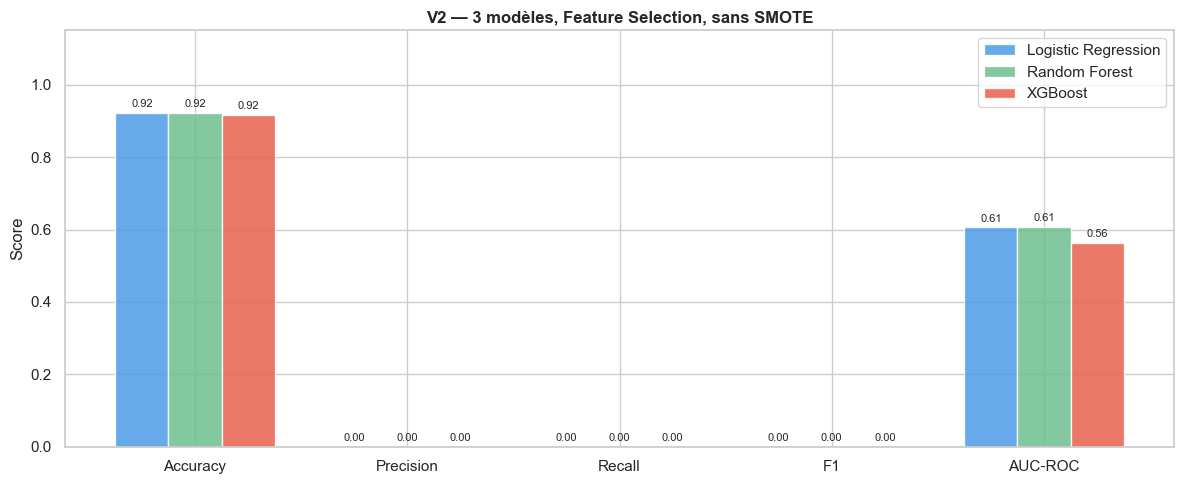

In [26]:
# Barplot comparatif des métriques
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
colors       = ['#4C9BE8', '#6DBF8E', '#E8614C']

fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(metrics_cols))
width = 0.25

for i, (name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics_cols]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=colors[i], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_cols)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('V2 — 3 modèles, Feature Selection, sans SMOTE',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

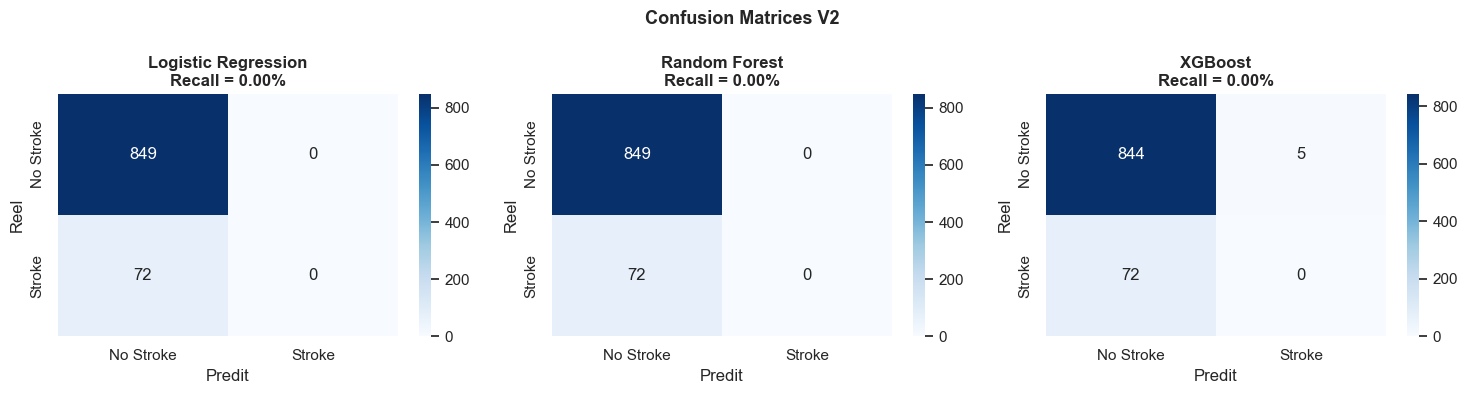

In [27]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, pipeline) in enumerate(trained_models.items()):
    y_pred     = pipeline.predict(X_test)
    cm         = confusion_matrix(y_test, y_pred)
    recall_val = recall_score(y_test, y_pred, zero_division=0)

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['No Stroke', 'Stroke'],
        yticklabels=['No Stroke', 'Stroke'],
        ax=axes[i]
    )
    axes[i].set_title(f'{name}\nRecall = {recall_val:.2%}', fontweight='bold')
    axes[i].set_ylabel('Reel')
    axes[i].set_xlabel('Predit')

plt.suptitle('Confusion Matrices V2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

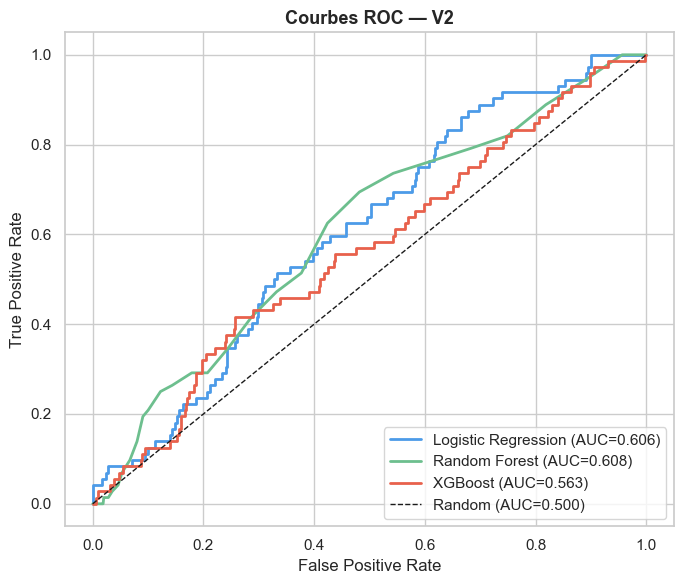

In [28]:
# Courbes ROC
fig, ax = plt.subplots(figsize=(7, 6))

for i, (name, pipeline) in enumerate(trained_models.items()):
    y_prob      = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc         = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=colors[i], linewidth=2,
            label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Courbes ROC — V2', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Analyse des erreurs — Faux Négatifs

Les **faux négatifs** sont les erreurs les plus graves médicalement —  
un patient avec AVC prédit comme sain.  

On analyse le profil des patients mal classifiés par le meilleur modèle.

Meilleur modèle : Logistic Regression
  Faux Négatifs (AVC manqués)   : 72
  Faux Positifs (fausse alarme) : 0
  Vrais Positifs (AVC détectés) : 0

=== Profil moyen — Faux Négatifs vs Vrais Positifs ===


,Faux Négatifs (manqués),Vrais Positifs (détectés)
gender,1.542,NaN
age,2.389,NaN
Race,2.986,NaN
Marital status,2.250,NaN
alcohol,0.694,NaN
smoke,0.681,NaN
sleep disorder,1.722,NaN
Health Insurance,1.097,NaN
General health condition,3.583,NaN
depression,1.333,NaN


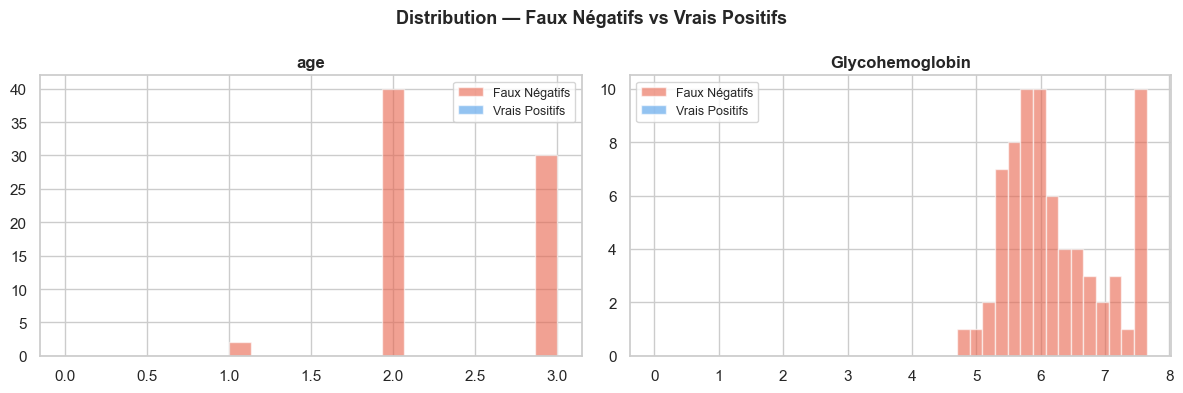

In [29]:
# Meilleur modèle selon Recall
best_name_err  = results_df['Recall'].idxmax()
best_model_err = trained_models[best_name_err]

y_pred_best = best_model_err.predict(X_test)

# Faux négatifs : stroke=1 prédit comme stroke=0
fn_mask = (y_test == 1) & (y_pred_best == 0)
fp_mask = (y_pred_best == 1) & (y_test == 0)
tp_mask = (y_test == 1) & (y_pred_best == 1)

print(f'Meilleur modèle : {best_name_err}')
print(f'  Faux Négatifs (AVC manqués)   : {fn_mask.sum()}')
print(f'  Faux Positifs (fausse alarme) : {fp_mask.sum()}')
print(f'  Vrais Positifs (AVC détectés) : {tp_mask.sum()}')

# Profil moyen FN vs VP
fn_df = X_test[fn_mask].copy()
tp_df = X_test[tp_mask].copy()

print('\n=== Profil moyen — Faux Négatifs vs Vrais Positifs ===')
compare = pd.DataFrame({
    'Faux Négatifs (manqués)'  : fn_df.mean().round(3),
    'Vrais Positifs (détectés)': tp_df.mean().round(3)
})
display(compare)

# Visualisation — distribution d'une variable clé entre FN et VP
key_vars = [c for c in ['age', 'Glycohemoglobin', 'Systolic blood pressure']
            if c in X_test.columns][:2]

if key_vars:
    fig, axes = plt.subplots(1, len(key_vars), figsize=(6 * len(key_vars), 4))
    if len(key_vars) == 1:
        axes = [axes]
    for ax, col in zip(axes, key_vars):
        ax.hist(fn_df[col], bins=15, alpha=0.6, color='#E8634C',
                label='Faux Négatifs', edgecolor='white')
        ax.hist(tp_df[col], bins=15, alpha=0.6, color='#4C9BE8',
                label='Vrais Positifs', edgecolor='white')
        ax.set_title(col, fontweight='bold')
        ax.legend(fontsize=9)
    plt.suptitle('Distribution — Faux Négatifs vs Vrais Positifs',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8. Constat V2 — Justification empirique

Malgré la Feature Selection et un meilleur preprocessing,  
le recall reste insuffisant — le déséquilibre 92%/8% n'est pas traité

In [30]:
print('=== Constat V2 ===')
print()
for name, row in results_df.iterrows():
    print(f'{name} :')
    print(f'  Accuracy : {row["Accuracy"]:.2%}')
    print(f'  Recall   : {row["Recall"]:.2%}  <- toujours faible malgré Feature Selection')
    print()

print('Conclusion :')
print('  La Feature Selection améliore légèrement les résultats.')
print('  Mais le déséquilibre 92%/8% empêche les modèles de détecter les AVC.')
print('  Recall encore insuffisant pour un usage médical.')

=== Constat V2 ===

Logistic Regression :
  Accuracy : 92.18%
  Recall   : 0.00%  <- toujours faible malgré Feature Selection

Random Forest :
  Accuracy : 92.18%
  Recall   : 0.00%  <- toujours faible malgré Feature Selection

XGBoost :
  Accuracy : 91.64%
  Recall   : 0.00%  <- toujours faible malgré Feature Selection

Conclusion :
  La Feature Selection améliore légèrement les résultats.
  Mais le déséquilibre 92%/8% empêche les modèles de détecter les AVC.
  Recall encore insuffisant pour un usage médical.


## 9. Sauvegarde — `pipeline.pkl` + `features.pkl`

In [31]:
# Meilleur modèle selon Recall
best_name     = results_df['Recall'].idxmax()
best_pipeline = trained_models[best_name]

print(f'Meilleur modèle selon Recall : {best_name}')
print(f'  Recall  : {results_df.loc[best_name, "Recall"]:.4f}')
print(f'  AUC-ROC : {results_df.loc[best_name, "AUC-ROC"]:.4f}')

with open('pipeline_v2.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

with open('features_v2.pkl', 'wb') as f:
    pickle.dump(SELECTED_FEATURES, f)

print()
print('Artefacts sauvegardés :')
print(f'  pipeline_v2.pkl — {best_name}')
print(f'  features_v2.pkl — {len(SELECTED_FEATURES)} features sélectionnées')

Meilleur modèle selon Recall : Logistic Regression
  Recall  : 0.0000
  AUC-ROC : 0.6063

Artefacts sauvegardés :
  pipeline_v2.pkl — Logistic Regression
  features_v2.pkl — 17 features sélectionnées


In [32]:
# ── Sauvegarde du dataset après feature selection ──────────────────────────
df_selected = df[SELECTED_FEATURES + [TARGET]]
df_selected.to_csv(FEATURES_PATH, index=False)
print(f"df_features.csv sauvegardé : {df_selected.shape[0]} lignes x {df_selected.shape[1]} colonnes")

df_features.csv sauvegardé : 4603 lignes x 18 colonnes
